# Pendulum Single Model Training

This notebook demonstrates:
1. Generating synthetic pendulum data
2. Training a single LFADS model
3. Analyzing and visualizing the results

In [1]:
# Import required libraries
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pickle
import yaml
import importlib

# Add src to path if needed
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import lfadsci
import lfadsci.run_utils
import lfadsci.shared_utils
import lfadsci.model
import lfadsci.utils_pendulum

# Enable inline plotting
%matplotlib inline

2026-02-27 23:00:14.014318: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/cuda/lib64:
2026-02-27 23:00:14.014335: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


## 1. Set Configuration Parameters

Define the model and training parameters for the pendulum task.

In [ ]:
# Set random seed for reproducibility
seed = 98
np.random.seed(seed)

# Configuration parameters
config = {
    'seed': seed,
    'data_seed': seed,
    'batch_size': 512,
    'train_frac': 0.6,
    'val_frac': 0.2,
    'test_frac': 0.2,
    'outputDir': './pendulum_single_run_output',
    'mode': 'train',
    
    # Training parameters
    'lr_init': 0.01,
    'lr_stop': 1e-5,
    'n_steps': 10000,
    'decay_factor': 0.95,
    'patience_till_lr_decay': 6,
    'save_freq': 1000,
    
    # Dataset configuration
    'dataset': {
        'name': 'pendulum'
    },
    
    # Model configuration
    'model': {
        'factors': 100,
        'ic_dim': 5,
        'bias_dim': 5,
        'n_hidden_encode_ic': 100,
        'n_hidden_encode_bias': 100,
        'n_hidden_encode_tv_input': 100,
        'n_hidden_decode': 200,
        'n_dynamics': 2,
        'dropout_rate': 0.0,
        'lam_predict': 0.0,
        'lam_kl_ic': 1.0,
        'lam_kl_bias': 1.0,
        'lam_kl_tv_inp': 1.0,
        'lam_l2': 0,
        'tv_input_dim': 1,
        'tv_input_smoothness_alpha': 0.0,
        'noise_stddev': 0.0,
        'generator_type': 'gru',
        'use_bias': True,
        'use_tv_input': False,
        'kl_warmup_start': 0,
        'kl_warmup_end': 2000,
    }
}

# Create output directory
os.makedirs(config['outputDir'], exist_ok=True)

print("Configuration set successfully!")
print(f"Output directory: {config['outputDir']}")

Configuration set successfully!
Output directory: ~/users/nishalps/fits


## 2. Generate Pendulum Data

Generate synthetic neural data from pendulum dynamics with different gravity values.

Generating pendulum data...
............................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................

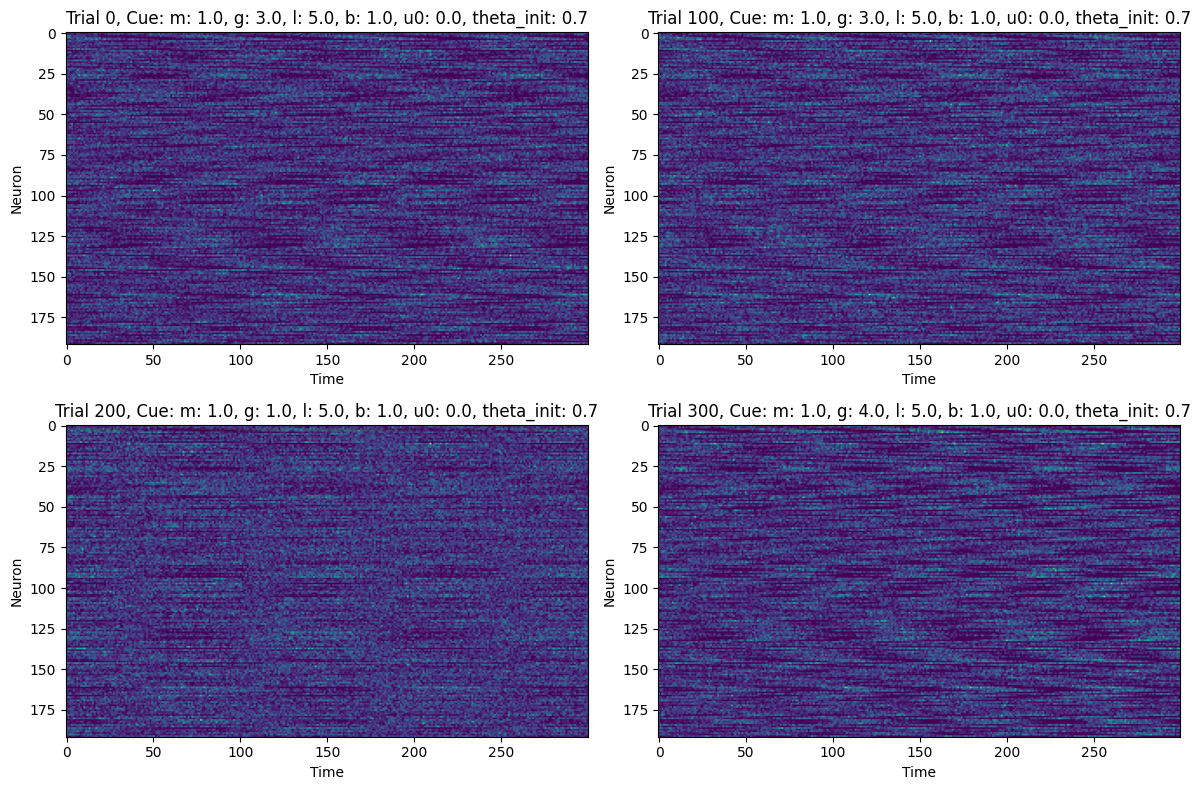

In [3]:
# Generate pendulum data
print("Generating pendulum data...")
neural_trials, cues_trials, delays_trials, session_trials = lfadsci.utils_pendulum.get_data(
    n_trials_total=1000,
    theta_init_randomize=False,
    b_randomize=False,
    g_randomize=True
)

print(f"Data shape: {neural_trials.shape}")
print(f"Number of trials: {len(neural_trials)}")
print(f"Time steps per trial: {neural_trials.shape[1]}")
print(f"Number of neurons: {neural_trials.shape[2]}")

# Visualize sample trials
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(neural_trials[i*100].T, aspect='auto', cmap='viridis')
    ax.set_xlabel('Time')
    ax.set_ylabel('Neuron')
    cues = cues_trials[i*100].split(',')
    ax.set_title(f'Trial {i*100}, Cue: m: {cues[0]}, g: {cues[1]}, l: {cues[2]}, b: {cues[3]}, u0: {cues[4]}, theta_init: {cues[5]}')
plt.tight_layout()
plt.show()

## 3. Prepare Data for Training

Split data into train/validation/test sets and create data generators.

In [4]:
# Prepare data using the shared utilities
print("Preparing data generators...")

data_list = [{
    'neural': neural_trials,
    'cues': cues_trials,
    'delays': delays_trials,
    'session_id': session_trials,
    'task': 'pendulum'
}]

datagenerator_combined, datasets_list = lfadsci.shared_utils.combine_datasets(
    data_list,
    batch_sz=config['batch_size'],
    train_frac=config['train_frac'],
    val_frac=config['val_frac'],
    test_frac=config['test_frac'],
    seed=config['data_seed'],
    data_weight=[1.0]
)

data = {
    'datagenerator': datagenerator_combined,
    'datasets': datasets_list,
    'data_val_weight': [1.0]
}

print(f"Training trials: {len(datasets_list[0]['train']['neural'])}")
print(f"Validation trials: {len(datasets_list[0]['eval']['neural'])}")
print(f"Test trials: {len(datasets_list[0]['test']['neural'])}")

n_channels = [dataset['train']['neural'].shape[-1] for dataset in data['datasets']]
print(f"Number of channels: {n_channels}")

Preparing data generators...
Original data weights: [1.0]
Rescaled data weights: [1.] to account for  different number of samples accross datasets.
Number of repeats per dataset: [100]
Repeating data 0: 100 times
Repeating data 0: 100 times
Repeating data 0: 100 times
Training trials: 600
Validation trials: 200
Test trials: 201
Number of channels: [192]


2026-02-27 23:00:20.674235: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-02-27 23:00:20.675970: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-02-27 23:00:20.677777: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/cuda/lib64:
2026-02-27 23:00:20.677866: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/cuda/lib64:
2026-02-27 23:00:20.67

## 4. Build and Train LFADS Model

Create the LFADS model and train it on the pendulum data.

In [5]:
# Import TensorFlow and set seed
import tensorflow as tf
tf.random.set_seed(config['seed'])

print(f"TensorFlow version: {tf.__version__}")
print("Building LFADS model...")

# Load model from configuration
model = lfadsci.model.load_model_from_config(
    config,
    n_channels,
    model_filename=f"{config['outputDir']}/model"
)

print("Model built successfully!")
print(f"Model will be saved to: {config['outputDir']}/model")

TensorFlow version: 2.7.0
Building LFADS model...
Building initial condition encoder
Building bias encoder
mu_phi (None, 5) sig_phi (None, 5)
Model could not be loaded
Model built successfully!
Model will be saved to: ~/users/nishalps/fits/model


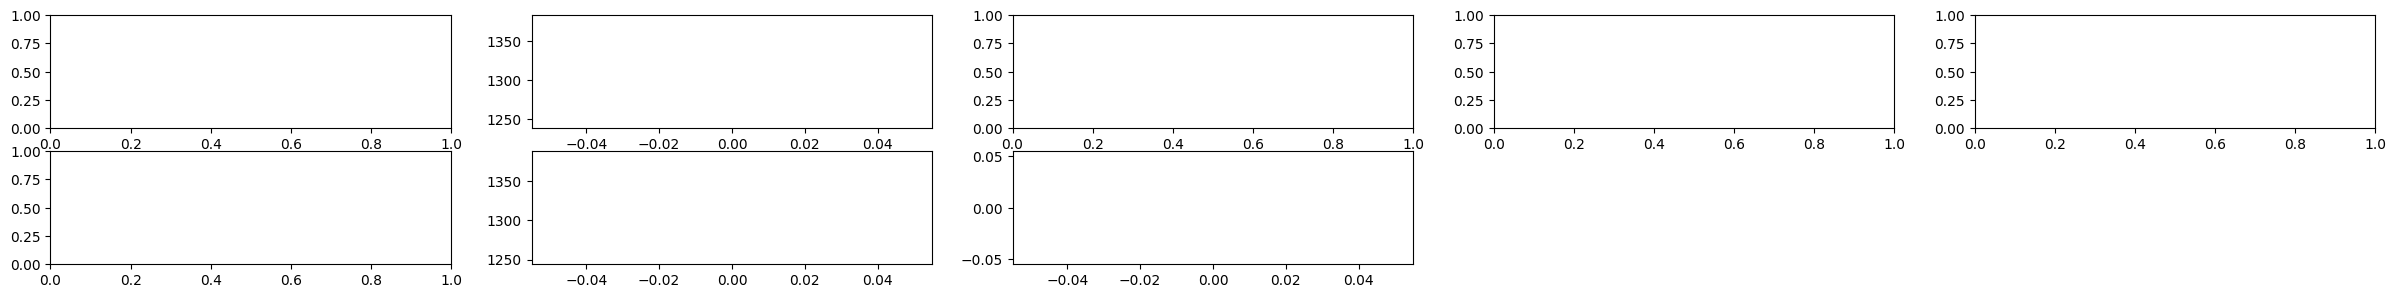

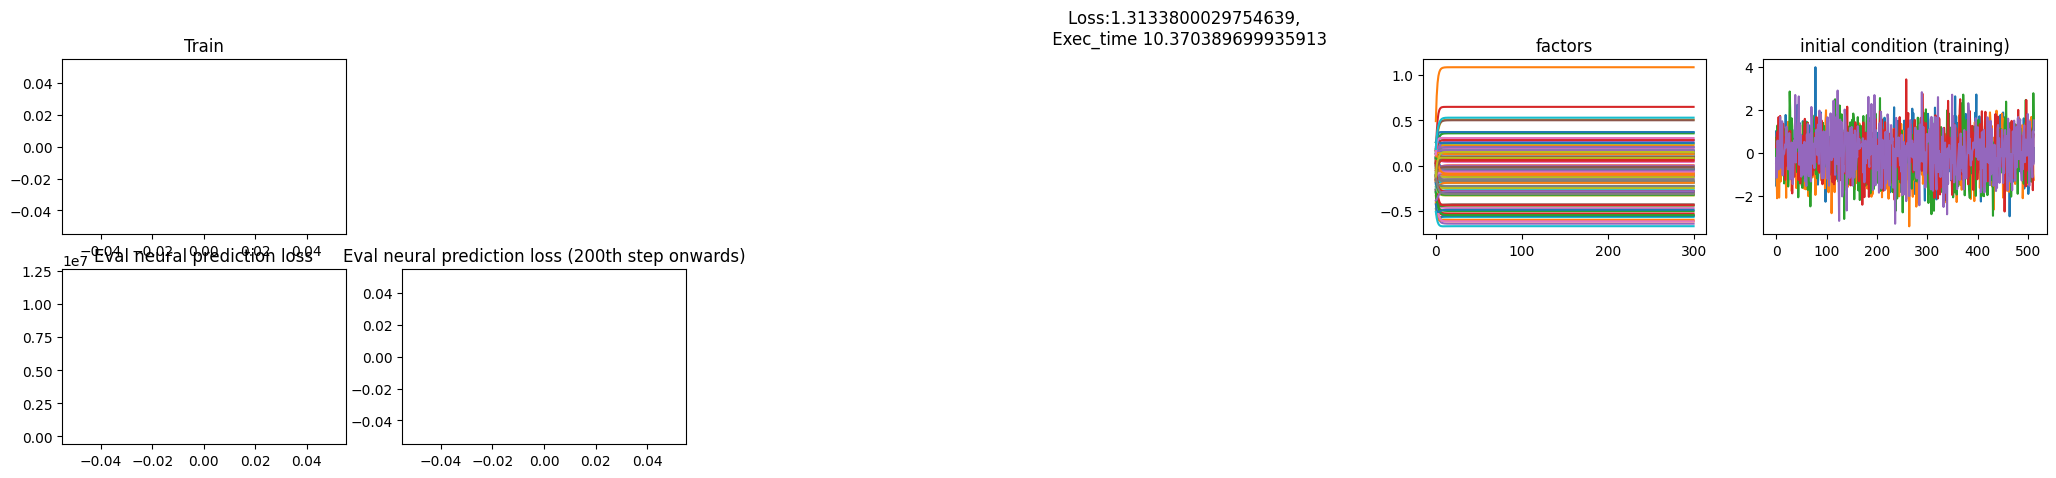

1
train_step (512, 300, 192) () tf.Tensor(1, shape=(), dtype=int32) learning rate 0.01
2
train_step (512, 300, 192) () tf.Tensor(1, shape=(), dtype=int32) learning rate 0.01


KeyboardInterrupt: 

In [ ]:
# Train the model
print("Starting training...")
print(f"Training for {config['n_steps']} steps")

import time
start_time = time.time()

loss_np = lfadsci.run_utils.train(
    data['datagenerator']['train'],
    model,
    data_test=[d['eval'] for d in data['datasets']],
    lr_init=config['lr_init'],
    lr_stop=config['lr_stop'],
    lams=None,
    n_steps=config['n_steps'],
    to_plot=False,
    kl_warmup_start=[config['model']['kl_warmup_start']],
    kl_warmup_end=[config['model']['kl_warmup_end']],
    decay_factor=config['decay_factor'],
    gradient_clipping_norm=0.1,
    savefile=f"{config['outputDir']}/model",
    n_eval_samples=None,
    patience_till_lr_decay=config['patience_till_lr_decay'],
    save_freq=config['save_freq'],
    data_val_weight=data['data_val_weight']
)

training_time = time.time() - start_time
print(f"Training completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(loss_np)
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.show()

## 5. Load Trained Model and Generate Results

Load the trained model checkpoint and generate posterior samples.

In [14]:
# Load the trained model
print("Loading trained model...")
model.load(f"{config['outputDir']}/model")
print("Model loaded successfully!")

# Generate results using posterior sampling
print("Generating results with posterior sampling...")
results = lfadsci.shared_utils.compile_results(
    model,
    datasets_list[0],
    n_samples=100,
    compute_kinematic_r2=False
)

print("Results compiled!")
print(f"Available partitions: {list(results.keys())}")
print(f"Available features in 'train': {list(results['train'].keys())}")

Loading trained model...


NotFoundError: Unsuccessful TensorSliceReader constructor: Failed to find any matching files for ~/users/nishalps/fits/model_encoder_ic

In [15]:
config['outputDir']

'~/users/nishalps/fits'

## 6. Fixed Point Analysis

Perform fixed point finding and eigenvalue analysis.

In [ ]:
# Perform fixed point analysis
print("Running fixed point analysis...")

for partition in ['train', 'test', 'eval']:
    session_id = np.array(datasets_list[0][partition]['session'][0, 0])
    print(f'Running fixed point finding for partition: {partition}')
    
    results = lfadsci.shared_utils.complete_fixed_point_analysis(
        model,
        results,
        EPS1=1e-7,
        get_fixed_points_only=False,
        partition=partition,
        to_plot=False,
        session_id=session_id
    )

print("Fixed point analysis completed!")

# Save results
pickle.dump(
    {'results_list': [results]},
    open(f"{config['outputDir']}/results_full.pkl", 'wb')
)
print(f"Results saved to {config['outputDir']}/results_full.pkl")

## 7. Visualize Results

Plot the learned representations and dynamics.

In [ ]:
# Extract cues (gravity values) for visualization
partition_use = 'train'
datasets = datasets_list[0]
cues = np.array([float(c.split(',')[1]) for c in datasets[partition_use]['cues']])

print(f"Number of conditions (unique gravity values): {len(np.unique(cues))}")
print(f"Gravity values: {sorted(np.unique(cues))}")

In [ ]:
# Visualize fixed points in PCA space
from sklearn.decomposition import PCA

# Get fixed points
if 'fixed_points_filtered' in results['train'].keys():
    fixed_points = results['train']['fixed_points_filtered']
    print(f"Number of fixed points found: {len(fixed_points)}")
    
    # Extract fixed point locations
    fp_locations = np.array([fp['x'] for fp in fixed_points])
    
    # PCA projection
    pca = PCA(n_components=2)
    fp_2d = pca.fit_transform(fp_locations)
    
    # Extract corresponding cues for each fixed point
    fp_cues = []
    for fp in fixed_points:
        trial_idx = fp['trial_idx']
        fp_cues.append(cues[trial_idx])
    fp_cues = np.array(fp_cues)
    
    # Plot
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(fp_2d[:, 0], fp_2d[:, 1], 
                         c=fp_cues, cmap='hsv', s=50, 
                         vmin=0.5, vmax=4.5, alpha=0.7)
    plt.colorbar(scatter, label='Gravity (g)')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.title('Fixed Points in PCA Space')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No fixed points found in results")

In [ ]:
# Plot neural trajectories in state space
print("Plotting neural trajectories...")

# Get states for a subset of trials
states = results['train']['state']
print(f"State shape: {states.shape}")

# Project to PCA space
n_trials_plot = 50
states_subset = states[:n_trials_plot, :, :]
states_2d_all = states_subset.reshape(-1, states_subset.shape[-1])

pca = PCA(n_components=2)
states_2d = pca.fit_transform(states_2d_all)
states_2d = states_2d.reshape(n_trials_plot, states_subset.shape[1], 2)

# Plot trajectories colored by gravity
fig, ax = plt.subplots(figsize=(10, 8))

for i in range(n_trials_plot):
    g_val = cues[i]
    color = plt.cm.hsv((g_val - 0.5) / 4.0)
    ax.plot(states_2d[i, :, 0], states_2d[i, :, 1], 
           color=color, alpha=0.3, linewidth=1)
    ax.plot(states_2d[i, 0, 0], states_2d[i, 0, 1], 
           'o', color=color, markersize=4)

plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('Neural Trajectories in State Space (colored by gravity)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Visualize bias samples (if using bias model)
if config['model']['use_bias'] and 'bias_sample' in results['train'].keys():
    print("Visualizing bias samples...")
    
    bias_samples = results['train']['bias_sample']
    print(f"Bias samples shape: {bias_samples.shape}")
    
    # PCA on bias samples
    pca_bias = PCA(n_components=2)
    bias_2d = pca_bias.fit_transform(bias_samples)
    
    plt.figure(figsize=(10, 6))
    
    # Plot all gravity values
    scatter = plt.scatter(bias_2d[:, 0], bias_2d[:, 1], 
                         c=cues, cmap='hsv', s=30, alpha=0.6,
                         vmin=0.5, vmax=4.5)
    plt.colorbar(scatter, label='Gravity (g)')
    plt.xlabel('Bias PC 1')
    plt.ylabel('Bias PC 2')
    plt.title('Bias Samples Colored by Gravity')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Plot by specific gravity values
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    
    for iidx, (ax, g_val) in enumerate(zip(axes.flat, [None, 1.0, 2.0, 3.0, 4.0])):
        if g_val is None:
            idx_plot = np.arange(bias_2d.shape[0])
            title = 'All conditions'
        else:
            idx_plot = np.where(np.abs(cues - g_val) < 0.1)[0]
            title = f'g = {g_val}'
        
        if iidx == 0:
            # Get limits from first plot
            scatter = ax.scatter(bias_2d[idx_plot, 0], bias_2d[idx_plot, 1],
                               c=cues[idx_plot], cmap='hsv', s=20, alpha=0.6,
                               vmin=0.5, vmax=4.5)
            xlim = ax.get_xlim()
            ylim = ax.get_ylim()
        else:
            ax.scatter(bias_2d[idx_plot, 0], bias_2d[idx_plot, 1],
                      c=cues[idx_plot], cmap='hsv', s=20, alpha=0.6,
                      vmin=0.5, vmax=4.5)
            ax.set_xlim(xlim)
            ax.set_ylim(ylim)
        
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Bias not used in model or bias_sample not available")

In [ ]:
# Plot initial condition samples
if 'ic_sample' in results['train'].keys():
    print("Visualizing initial condition samples...")
    
    ic_samples = results['train']['ic_sample']
    print(f"IC samples shape: {ic_samples.shape}")
    
    # PCA on IC samples
    pca_ic = PCA(n_components=2)
    ic_2d = pca_ic.fit_transform(ic_samples)
    
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(ic_2d[:, 0], ic_2d[:, 1], 
                         c=cues, cmap='hsv', s=30, alpha=0.6,
                         vmin=0.5, vmax=4.5)
    plt.colorbar(scatter, label='Gravity (g)')
    plt.xlabel('IC PC 1')
    plt.ylabel('IC PC 2')
    plt.title('Initial Condition Samples Colored by Gravity')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
# Eigenvalue analysis
if 'jacobians' in results['train'].keys():
    print("Performing eigenvalue analysis...")
    
    # Use the utility function from utils_pendulum
    fig, ax = plt.subplots(figsize=(8, 8))
    
    lfadsci.utils_pendulum.ev_plot_pendulum(
        datasets_list[0],
        results,
        ax=ax,
        sz_scale=1,
        movement_colors=True,
        cmap='hsv'
    )
    
    ax.set_xlim([0.8, 1.1])
    ax.set_ylim([-5, 5])
    ax.set_xlabel('Real Part')
    ax.set_ylabel('Imaginary Part')
    ax.set_title('Eigenvalue Analysis (colored by gravity)')
    ax.axvline(1.0, color='k', linestyle='--', alpha=0.5, label='Unit circle')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Jacobians not available in results")

In [ ]:
# 3D visualization of states and fixed points
if 'fixed_points_filtered' in results['train'].keys():
    print("Creating 3D visualization...")
    
    # Get states starting from timestep 100 onwards
    states_subset = states[:50, 100:, :]
    
    lfadsci.utils_pendulum.plot_states_fps(
        cues[:50],
        states_subset,
        results['train']['fixed_points_filtered'],
        n_comps_cis=2,
        elev=0,
        azim=-60,
        alpha_state=0.3,
        alpha_fp=1,
        color_fixedpoints=config['model']['use_bias'],
        fp_marker='*',
        fp_markersize=50,
        state_lw=0.5,
        add_cis_dimension=True
    )
    
    plt.suptitle('3D State Space with Fixed Points', fontsize=14)
    plt.tight_layout()
    plt.show()

## 8. Summary

The notebook has successfully:
1. ✓ Generated synthetic pendulum data with varying gravity values
2. ✓ Trained an LFADS model on the data
3. ✓ Performed fixed point analysis
4. ✓ Visualized the learned representations

The model learns to represent different pendulum dynamics (gravity values) through:
- Distinct fixed points for each condition
- Bias vectors that capture context-dependent dynamics
- Smooth trajectories in latent space

In [ ]:
# Print final summary
print("=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)
print(f"Model type: LFADS")
print(f"Use bias: {config['model']['use_bias']}")
print(f"Use TV input: {config['model']['use_tv_input']}")
print(f"Bias dimension: {config['model']['bias_dim']}")
print(f"IC dimension: {config['model']['ic_dim']}")
print(f"Hidden decode: {config['model']['n_hidden_decode']}")
print(f"Training steps: {config['n_steps']}")
print(f"Training time: {training_time:.2f} seconds")
print(f"Final loss: {loss_np[-1]:.4f}")
print(f"\nNumber of conditions: {len(np.unique(cues))}")
print(f"Number of fixed points: {len(results['train']['fixed_points_filtered']) if 'fixed_points_filtered' in results['train'] else 'N/A'}")
print(f"\nOutput directory: {config['outputDir']}")
print("=" * 60)